In [ ]:
SUBGROUP_DATA = {
    'Age': {
        '<30':   {'to_mean':  217.8, 'to_std': 11.8, 'oracle':  246.3, 'n': 1655},
        '30-40': {'to_mean':  183.0, 'to_std': 12.6, 'oracle':  175.3, 'n': 2683},
        '40-50': {'to_mean':   23.1, 'to_std': 12.6, 'oracle':   11.0, 'n':  866},
    },
    'Education': {
        'HS dip':    {'to_mean': 176.8, 'to_std': 16.5, 'oracle': 169.4, 'n': 2849},
        'no HS dip': {'to_mean': 138.1, 'to_std':  9.9, 'oracle': 150.2, 'n': 2596},
    },
    'Prior labor': {
        'ever earned':  {'to_mean': 188.7, 'to_std': 20.0, 'oracle': 218.2, 'n': 3127},
        'never earned': {'to_mean': 104.0, 'to_std':  14.8, 'oracle':  92.0, 'n': 2318},
    },
    'Ethnicity': {
        'white': {'to_mean': 175.7, 'to_std': 11.7, 'oracle': 152.9, 'n': 2827},
        'hisp':  {'to_mean':  305.3, 'to_std': 24.6, 'oracle': 283.9, 'n': 1487},
        'black': {'to_mean':  48.7, 'to_std': 12.8, 'oracle':  63.6, 'n':  861},
    },
}

# Quick sanity print
for cat, groups in SUBGROUP_DATA.items():
    print(f'{cat}:')
    for name, v in groups.items():
        print(f'  {name:>14s}  TO={v["to_mean"]:+7.1f} +/- {v["to_std"]:5.1f}   oracle={v["oracle"]:+7.1f}   n={v["n"]:>5d}')

Age:
             <30  TO= +217.8 +/-  11.8   oracle= +246.3   n= 1655
           30-40  TO= +183.0 +/-  12.6   oracle= +175.3   n= 2683
           40-50  TO=  +23.1 +/-  12.6   oracle=  +11.0   n=  866
Education:
          HS dip  TO= +176.8 +/-  16.5   oracle= +169.4   n= 2849
       no HS dip  TO= +138.1 +/-   9.9   oracle= +150.2   n= 2596
Prior labor:
     ever earned  TO= +188.7 +/-  20.0   oracle= +218.2   n= 3127
    never earned  TO= +104.0 +/-  14.8   oracle=  +92.0   n= 2318
Ethnicity:
           white  TO= +175.7 +/-  11.7   oracle= +152.9   n= 2827
            hisp  TO= +305.3 +/-  24.6   oracle= +283.9   n= 1487
           black  TO=  +48.7 +/-  12.8   oracle=  +63.6   n=  861


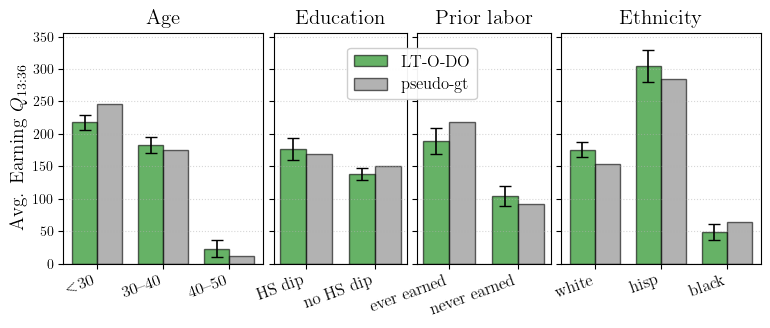

In [35]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'text.latex.preamble': r'\usepackage{amsmath}',
})

# LaTeX-friendly subgroup labels (overrides the bare strings in SUBGROUP_DATA keys)
LABEL_TEX = {
    '<30':          r'$<\!30$',
    '30-40':        r'$30\text{--}40$',
    '40-50':        r'$40\text{--}50$',
    '>=50':         r'$\geq\!50$',
    'HS dip':       r'HS dip',
    'no HS dip':    r'no HS dip',
    'ever earned':  r'ever earned',
    'never earned': r'never earned',
    'white':        r'white',
    'hisp':         r'hisp',
    'black':        r'black',
}

categories = list(SUBGROUP_DATA.keys())
widths = [len(SUBGROUP_DATA[cat]) for cat in categories]
fig, axes = plt.subplots(1, len(categories), figsize=(9, 3.0),
                         gridspec_kw={'width_ratios': widths, 'wspace': 0.06},
                         sharey=True)

bar_w = 0.38
TO_COLOR = 'green'
ORACLE_COLOR = 'gray'
BAR_ALPHA = 0.6

# global y-range with margin so error bars and tall oracle bars all fit
all_top, all_bot = [], []
for cat, groups in SUBGROUP_DATA.items():
    for v in groups.values():
        all_top += [v['to_mean'] + v['to_std'], v['oracle']]
        all_bot += [v['to_mean'] - v['to_std'], v['oracle']]
y_top = max(all_top) * 1.08
y_bot = min(min(all_bot), 0) * 1.18

# Only show one legend box located midway between the 2nd and 3rd panels.


for ax, cat in zip(axes, categories):
    groups = SUBGROUP_DATA[cat]
    n_g = len(groups)
    x = np.arange(n_g)
    labels = list(groups.keys())
    to_means = [groups[k]['to_mean'] for k in labels]
    to_stds  = [groups[k]['to_std']  for k in labels]
    oracle_means = [groups[k]['oracle'] for k in labels]

    ax.bar(x - bar_w/2, to_means, bar_w, yerr=to_stds, capsize=4,
           color=TO_COLOR, alpha=BAR_ALPHA, edgecolor='black',
           error_kw=dict(lw=1.2), label=r'LT-O-DO')
    ax.bar(x + bar_w/2, oracle_means, bar_w,
           color=ORACLE_COLOR, alpha=BAR_ALPHA, edgecolor='black',
           label=r'pseudo-gt')
    ax.set_xticks(x)
    ax.set_xticklabels([LABEL_TEX.get(k, k) for k in labels],
                       rotation=20, ha='right', fontsize=12)
    ax.set_title(cat, fontsize=15)
    ax.axhline(0, color='black', lw=0.8)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

axes[0].set_ylabel(r'Avg. Earning $Q_{13:36}$', fontsize=14)
axes[0].set_ylim(y_bot, y_top)

legend_handles, legend_labels = axes[0].get_legend_handles_labels()
legend_x = (axes[1].get_position().x1 + axes[2].get_position().x0) / 2
legend_y = (axes[1].get_position().y0 + axes[1].get_position().y1) / 2 * 1.5
fig.legend(legend_handles, legend_labels,
           loc='center', bbox_to_anchor=(legend_x, legend_y ),
           fontsize=12, framealpha=0.95)

plt.savefig('gain_subgroup_bars.pdf', bbox_inches='tight')
plt.show()